# World Happiness Analysis (2015–2019)

## Introduction
This case study analyzes global happiness trends using the World Happiness dataset across multiple years. The study focuses on understanding how different socio-economic factors influence happiness levels across countries and regions.

## Objectives
- Analyze trends in happiness scores over time
- Examine relationships between economic and social factors
- Compare regional variations in happiness
- Identify patterns and distributions in key indicators

## Dataset Description
The dataset contains country-wise happiness metrics for the years 2015 to 2019. Key variables include:
- Happiness Score
- GDP per capita
- Social support
- Health (Life Expectancy)
- Freedom to make life choices
- Generosity
- Perceptions of corruption
- Region

## Methodology
- Data cleaning and standardization across years
- Exploratory Data Analysis (EDA) using visualizations
- Statistical interpretation of trends and relationships

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn


## Q1: Trend Analysis of Global Happiness (2015–2019)

### Objective
To analyze how the average happiness score has changed over time across all countries.

### Approach
- Combine datasets from multiple years into a unified format
- Compute the average happiness score for each year
- Visualize the trend using a line chart

### Expected Outcome
Identify years with noticeable increases or decreases in global happiness and interpret possible reasons behind these changes.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df2015 = pd.read_csv('2015.csv')
df2016 = pd.read_csv('2016.csv')
df2017 = pd.read_csv('2017.csv')
df2018 = pd.read_csv('2018.csv')
df2019 = pd.read_csv('2019.csv')

def clean_2015(df):
    df = df.rename(columns={
        'Economy (GDP per Capita)': 'GDP per capita',
        'Family': 'Social support',
        'Health (Life Expectancy)': 'Health',
        'Trust (Government Corruption)': 'Corruption'
    })
    df['Year'] = 2015
    return df[['Country','Region','Year','Happiness Score','GDP per capita','Social support','Health','Freedom','Generosity','Corruption']]

def clean_2016(df):
    df = df.rename(columns={
        'Economy (GDP per Capita)': 'GDP per capita',
        'Family': 'Social support',
        'Health (Life Expectancy)': 'Health',
        'Trust (Government Corruption)': 'Corruption'
    })
    df['Year'] = 2016
    return df[['Country','Region','Year','Happiness Score','GDP per capita','Social support','Health','Freedom','Generosity','Corruption']]

def clean_2017(df):
    df = df.rename(columns={
        'Happiness.Score': 'Happiness Score',
        'Economy..GDP.per.Capita.': 'GDP per capita',
        'Family': 'Social support',
        'Health..Life.Expectancy.': 'Health',
        'Trust..Government.Corruption.': 'Corruption'
    })
    df['Year'] = 2017
    df['Region'] = None
    return df[['Country','Region','Year','Happiness Score','GDP per capita','Social support','Health','Freedom','Generosity','Corruption']]

def clean_2018(df):
    df = df.rename(columns={
        'Country or region': 'Country',
        'Score': 'Happiness Score',
        'Healthy life expectancy': 'Health',
        'Freedom to make life choices': 'Freedom',
        'Perceptions of corruption': 'Corruption'
    })
    df['Year'] = 2018
    df['Region'] = None
    return df[['Country','Region','Year','Happiness Score','GDP per capita','Social support','Health','Freedom','Generosity','Corruption']]

def clean_2019(df):
    df = df.rename(columns={
        'Country or region': 'Country',
        'Score': 'Happiness Score',
        'Healthy life expectancy': 'Health',
        'Freedom to make life choices': 'Freedom',
        'Perceptions of corruption': 'Corruption'
    })
    df['Year'] = 2019
    df['Region'] = None
    return df[['Country','Region','Year','Happiness Score','GDP per capita','Social support','Health','Freedom','Generosity','Corruption']]

df_all = pd.concat([
    clean_2015(df2015),
    clean_2016(df2016),
    clean_2017(df2017),
    clean_2018(df2018),
    clean_2019(df2019)
], ignore_index=True)

region_map = df_all[df_all['Year'] == 2015][['Country','Region']]
df_all = df_all.merge(region_map, on='Country', how='left', suffixes=('','_y'))
df_all['Region'] = df_all['Region'].fillna(df_all['Region_y'])
df_all = df_all.drop(columns=['Region_y'])

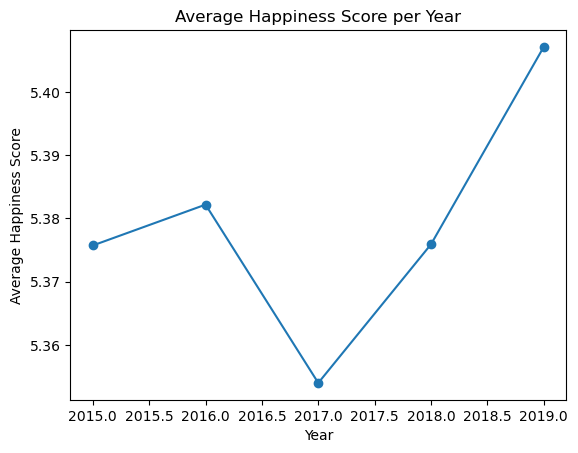

In [8]:
avg = df_all.groupby('Year')['Happiness Score'].mean()

plt.figure()
plt.plot(avg.index, avg.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Average Happiness Score')
plt.title('Average Happiness Score per Year')
plt.show()

### Result

The average happiness score shows a slight increase from 2015 to 2016, followed by a noticeable drop in 2017. After 2017, the scores steadily rise, reaching the highest value in 2019.

Overall, the trend indicates a temporary decline in global happiness around 2017, followed by recovery and improvement in subsequent years.

## Q2: Relationship between GDP per Capita and Happiness Score

### Objective
To examine how economic prosperity (GDP per capita) influences happiness levels across countries.

### Approach
- Create a scatter plot of GDP per capita vs Happiness Score
- Color points based on region to observe regional patterns
- Fit a regression line to identify the overall trend

### Expected Outcome
To determine whether higher GDP per capita is associated with higher happiness scores and assess the strength of this relationship.

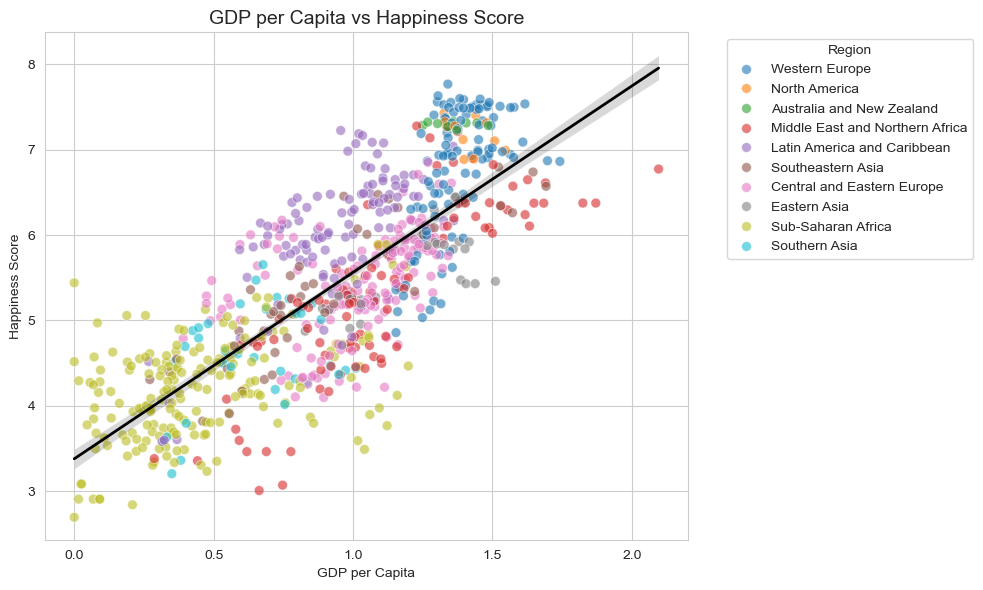

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.set_style("whitegrid")

sns.scatterplot(
    data=df_all,
    x='GDP per capita',
    y='Happiness Score',
    hue='Region',
    palette='tab10',
    alpha=0.6,
    s=50
)

sns.regplot(
    data=df_all,
    x='GDP per capita',
    y='Happiness Score',
    scatter=False,
    color='black',
    line_kws={'linewidth':2}
)

plt.title('GDP per Capita vs Happiness Score', fontsize=14)
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Region')
plt.tight_layout()

plt.show()

### Results and Interpretation

The refined scatter plot shows a clear positive relationship between GDP per capita and happiness score.

- Countries with higher GDP per capita generally exhibit higher happiness levels.
- The regression line indicates a strong positive correlation, suggesting that economic prosperity significantly contributes to well-being.
- However, the dispersion of points shows that countries with similar GDP levels can still have varying happiness scores, indicating the influence of non-economic factors.
- Regional clustering is visible, where developed regions tend to lie in the higher GDP–happiness range, while developing regions are concentrated in lower ranges.

Overall, GDP per capita is a strong predictor of happiness, but it does not fully explain global variations.

## Q3: Regional Comparison of Happiness Scores with Confidence Intervals

### Objective
To compare the average happiness scores across different regions and evaluate the consistency of these scores using 95% confidence intervals.

### Approach
- Group data by region
- Compute mean happiness score for each region
- Visualize using error bars representing 95% confidence intervals

### Expected Outcome
To identify which regions have more stable (consistent) happiness levels and which show greater variability.

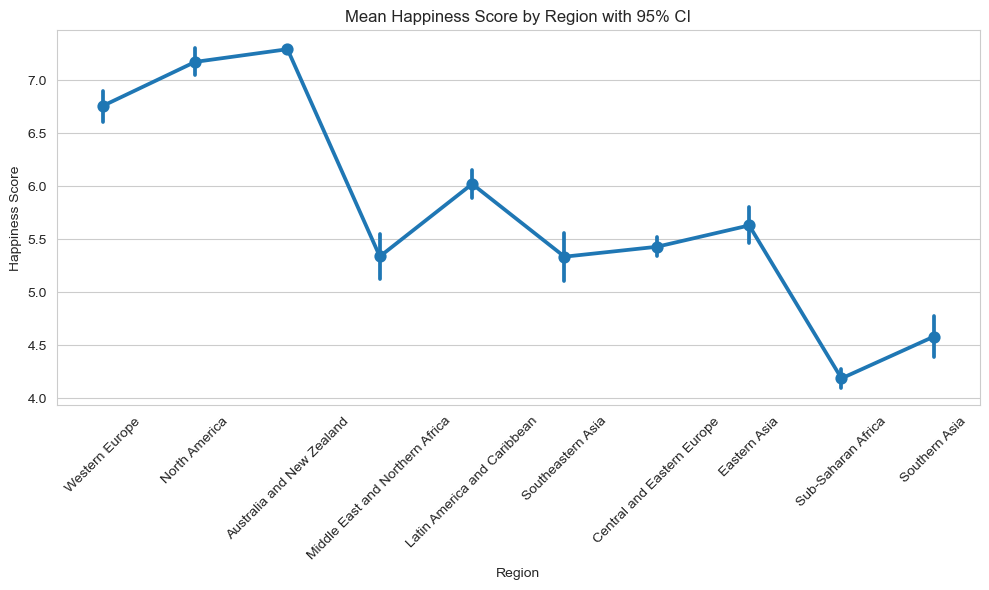

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.pointplot(
    data=df_all,
    x='Region',
    y='Happiness Score',
    errorbar=('ci', 95)
)

plt.xticks(rotation=45)
plt.title('Mean Happiness Score by Region with 95% CI')
plt.tight_layout()
plt.show()

### Results and Interpretation

The plot shows the mean happiness score for each region along with 95% confidence intervals.

- Australia and New Zealand, North America, and Western Europe have the highest average happiness scores.
- Sub-Saharan Africa and Southern Asia have the lowest average scores.
- Regions like Australia and New Zealand show smaller confidence intervals, indicating more consistent happiness levels.
- Regions such as the Middle East and Northern Africa and Latin America show wider intervals, suggesting greater variability.

Overall, developed regions exhibit both higher and more stable happiness, while developing regions show lower and more varied scores.

## Q4: Distribution of Happiness Scores Across Regions

### Objective
To compare the distribution of happiness scores for the top 5 and bottom 5 regions using density plots.

### Approach
- Identify top 5 and bottom 5 regions based on mean happiness score
- Plot KDE curves for each selected region on the same axes
- Analyze overlap and separation between distributions

### Expected Outcome
To understand how happiness distributions differ between high-performing and low-performing regions.

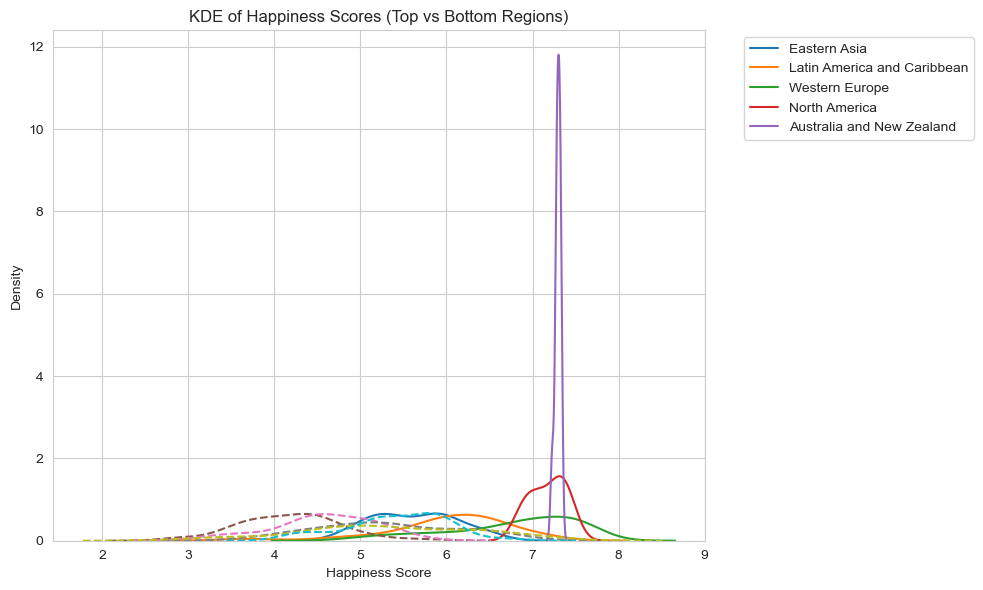

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

region_means = df_all.groupby('Region')['Happiness Score'].mean().sort_values()

bottom5 = region_means.head(5).index
top5 = region_means.tail(5).index

plt.figure(figsize=(10,6))

for region in top5:
    sns.kdeplot(
        df_all[df_all['Region'] == region]['Happiness Score'],
        label=region
    )

for region in bottom5:
    sns.kdeplot(
        df_all[df_all['Region'] == region]['Happiness Score'],
        linestyle='--'
    )

plt.title('KDE of Happiness Scores (Top vs Bottom Regions)')
plt.xlabel('Happiness Score')
plt.ylabel('Density')
plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

### Results and Interpretation

The KDE plot compares the distribution of happiness scores across the top-performing regions.

- Australia and New Zealand show a very sharp peak around higher happiness scores, indicating highly consistent and high well-being.
- Western Europe and North America also exhibit high happiness levels, with slightly wider distributions.
- Latin America and Eastern Asia show moderate distributions centered around mid-range happiness scores.
- The spread of curves indicates that while top regions generally cluster at higher scores, there is still some variation within regions.

Overall, top-performing regions are concentrated in the higher happiness range with relatively less variability, indicating both high and stable well-being.

## Q5: Joint Distribution of Freedom and Happiness

### Objective
To analyze how freedom to make life choices relates to happiness using a 2D density visualization.

### Approach
- Plot a 2D density (KDE) or histogram of Freedom vs Happiness Score
- Identify clusters and concentration regions

### Expected Outcome
To observe whether higher freedom levels correspond to higher happiness and identify clusters of countries.

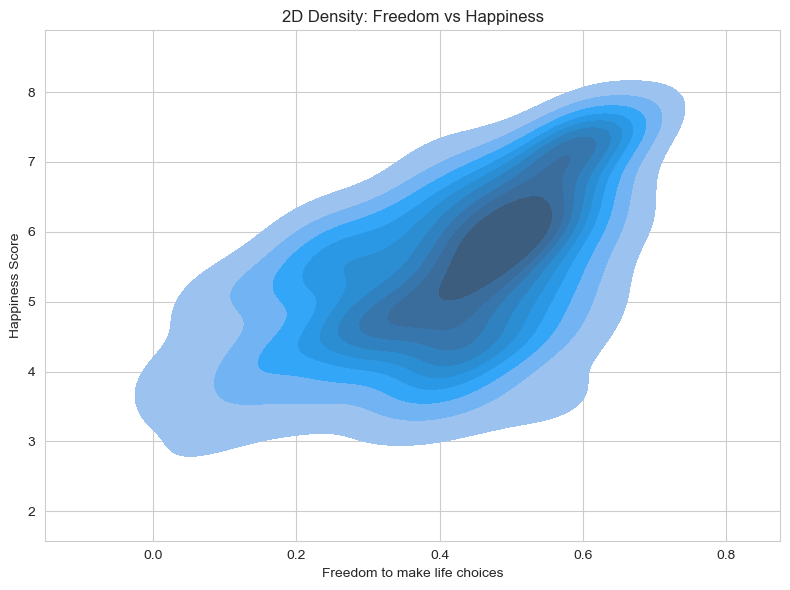

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.kdeplot(
    data=df_all,
    x='Freedom',
    y='Happiness Score',
    fill=True
)

plt.title('2D Density: Freedom vs Happiness')
plt.xlabel('Freedom to make life choices')
plt.ylabel('Happiness Score')
plt.tight_layout()
plt.show()

### Results and Interpretation

The 2D density plot reveals a clear positive association between freedom and happiness.

- The highest density region is concentrated around moderate to high freedom and mid-to-high happiness scores.
- The upward slope of the density contours indicates that countries with greater freedom tend to have higher happiness levels.
- Low freedom values are mostly associated with lower happiness scores, with fewer high-happiness observations in this range.
- The smooth gradient of density suggests a consistent relationship rather than isolated clusters.

Overall, the visualization confirms that freedom to make life choices is strongly linked to higher happiness levels across countries.

## Q6: Distribution of Generosity Scores

### Objective
To analyze the distribution of generosity scores across all countries and identify patterns such as skewness.

### Approach
- Plot a histogram of generosity scores
- Overlay a KDE curve to observe the distribution shape

### Expected Outcome
To determine whether generosity is evenly distributed or skewed across countries.

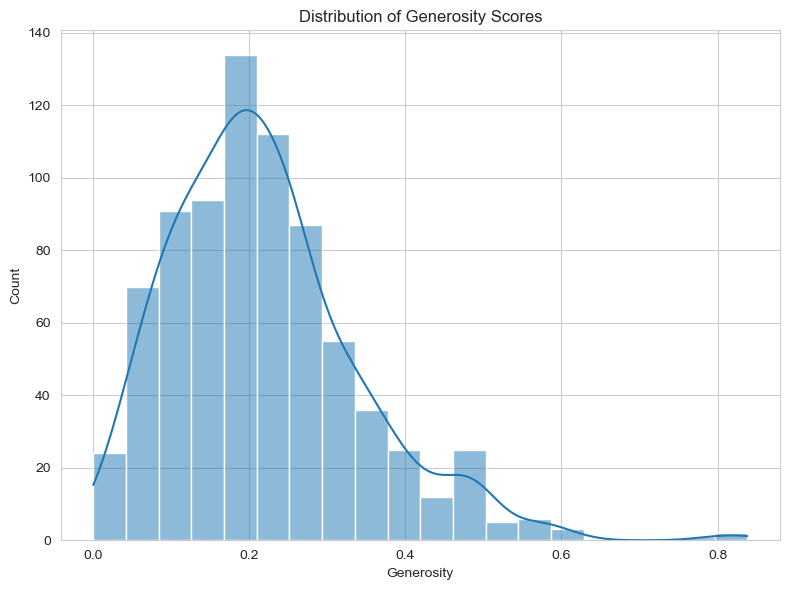

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.histplot(
    df_all['Generosity'],
    bins=20,
    kde=True
)

plt.title('Distribution of Generosity Scores')
plt.xlabel('Generosity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Results and Interpretation

The histogram and KDE curve indicate that generosity scores are positively skewed.

- The majority of countries have generosity values concentrated between approximately 0.1 and 0.3.
- The distribution has a long right tail, extending towards higher values, indicating fewer countries with high generosity.
- The peak around lower values shows that moderate generosity is most common globally.
- Very high generosity scores are rare and appear as outliers.

Overall, the distribution suggests that while most countries exhibit moderate generosity, only a small number demonstrate significantly higher levels.

## Q7: Multi-Aspect Visualization of Happiness Indicators

### Objective
To analyze multiple factors influencing happiness using a combined subplot visualization.

### Approach
A 2x2 grid of plots is created to examine:
- (a) Trend of GDP per capita over time
- (b) Relationship between social support and happiness
- (c) Distribution of generosity across regions
- (d) Correlation between key variables using a heatmap

### Expected Outcome
To gain a comprehensive understanding of how different factors contribute to happiness.

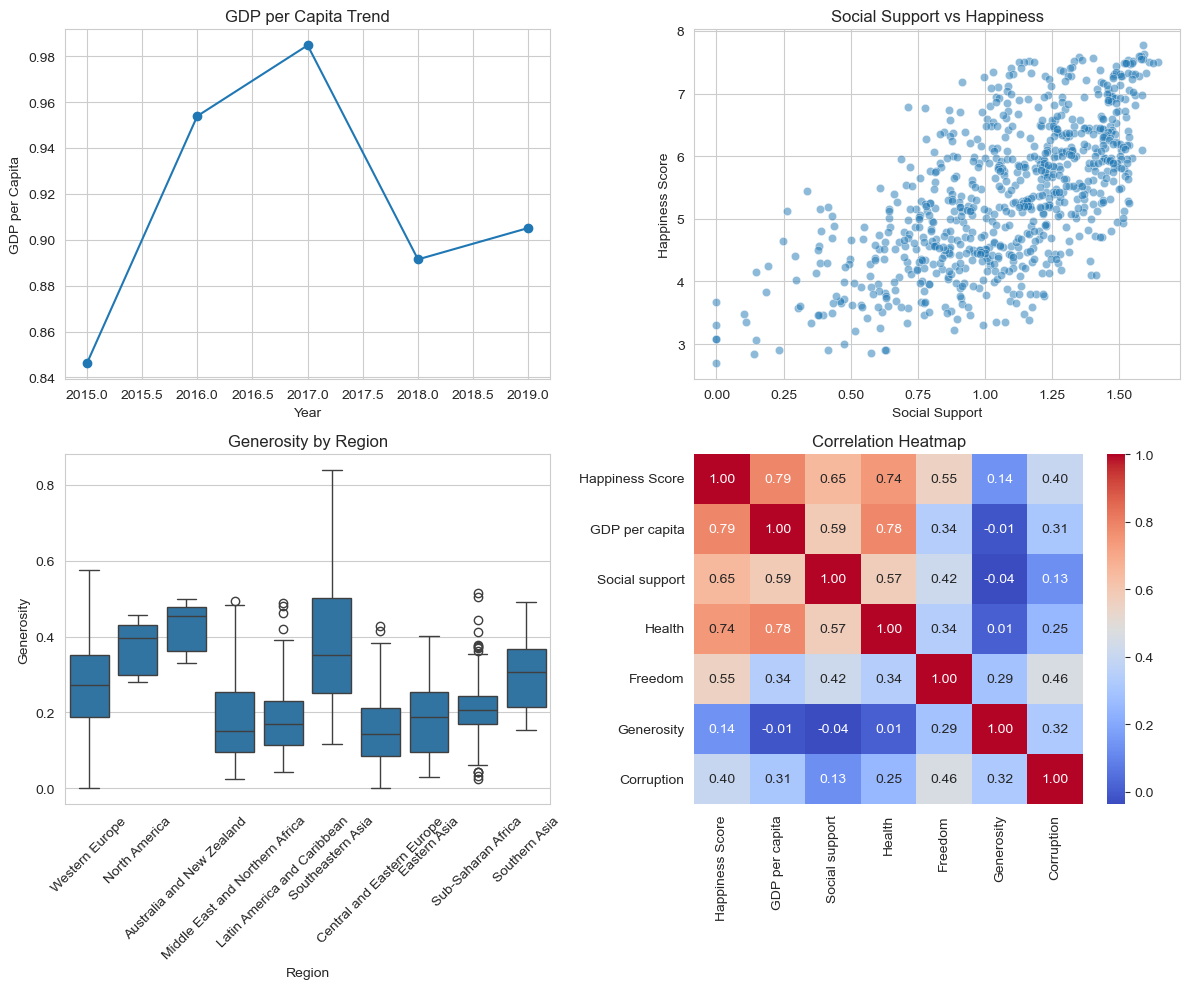

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12,10))

gdp_trend = df_all.groupby('Year')['GDP per capita'].mean()
axes[0,0].plot(gdp_trend.index, gdp_trend.values, marker='o')
axes[0,0].set_title('GDP per Capita Trend')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('GDP per Capita')

sns.scatterplot(data=df_all, x='Social support', y='Happiness Score', ax=axes[0,1], alpha=0.5)
axes[0,1].set_title('Social Support vs Happiness')
axes[0,1].set_xlabel('Social Support')
axes[0,1].set_ylabel('Happiness Score')

sns.boxplot(data=df_all, x='Region', y='Generosity', ax=axes[1,0])
axes[1,0].set_title('Generosity by Region')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_xlabel('Region')
axes[1,0].set_ylabel('Generosity')

corr = df_all[['Happiness Score','GDP per capita','Social support','Health','Freedom','Generosity','Corruption']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1,1])
axes[1,1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

### Results and Interpretation

The subplot provides a comprehensive view of multiple factors influencing happiness.

- The GDP per capita trend shows an overall increase from 2015 to 2017, followed by a slight decline and stabilization, indicating economic fluctuations over time.
- The scatter plot between social support and happiness reveals a strong positive relationship, where higher social support corresponds to higher happiness scores.
- The boxplot of generosity highlights clear regional differences, with some regions showing higher median generosity and others exhibiting wider variability.
- The correlation heatmap indicates that happiness score is strongly positively correlated with GDP per capita, health, and social support, while generosity shows a weak correlation.

Overall, the analysis demonstrates that happiness is influenced by a combination of economic, social, and health-related factors, with social support and GDP being key contributors.

## Q8: Regional Analysis of Health vs Happiness using FacetGrid

### Objective
To examine how health (life expectancy) influences happiness across different regions.

### Approach
- Use Seaborn FacetGrid to create separate scatter plots for each region
- Plot Health (Life Expectancy) vs Happiness Score
- Observe patterns and compare trends across regions

### Expected Outcome
To identify whether the relationship between health and happiness is consistent across regions or varies significantly.

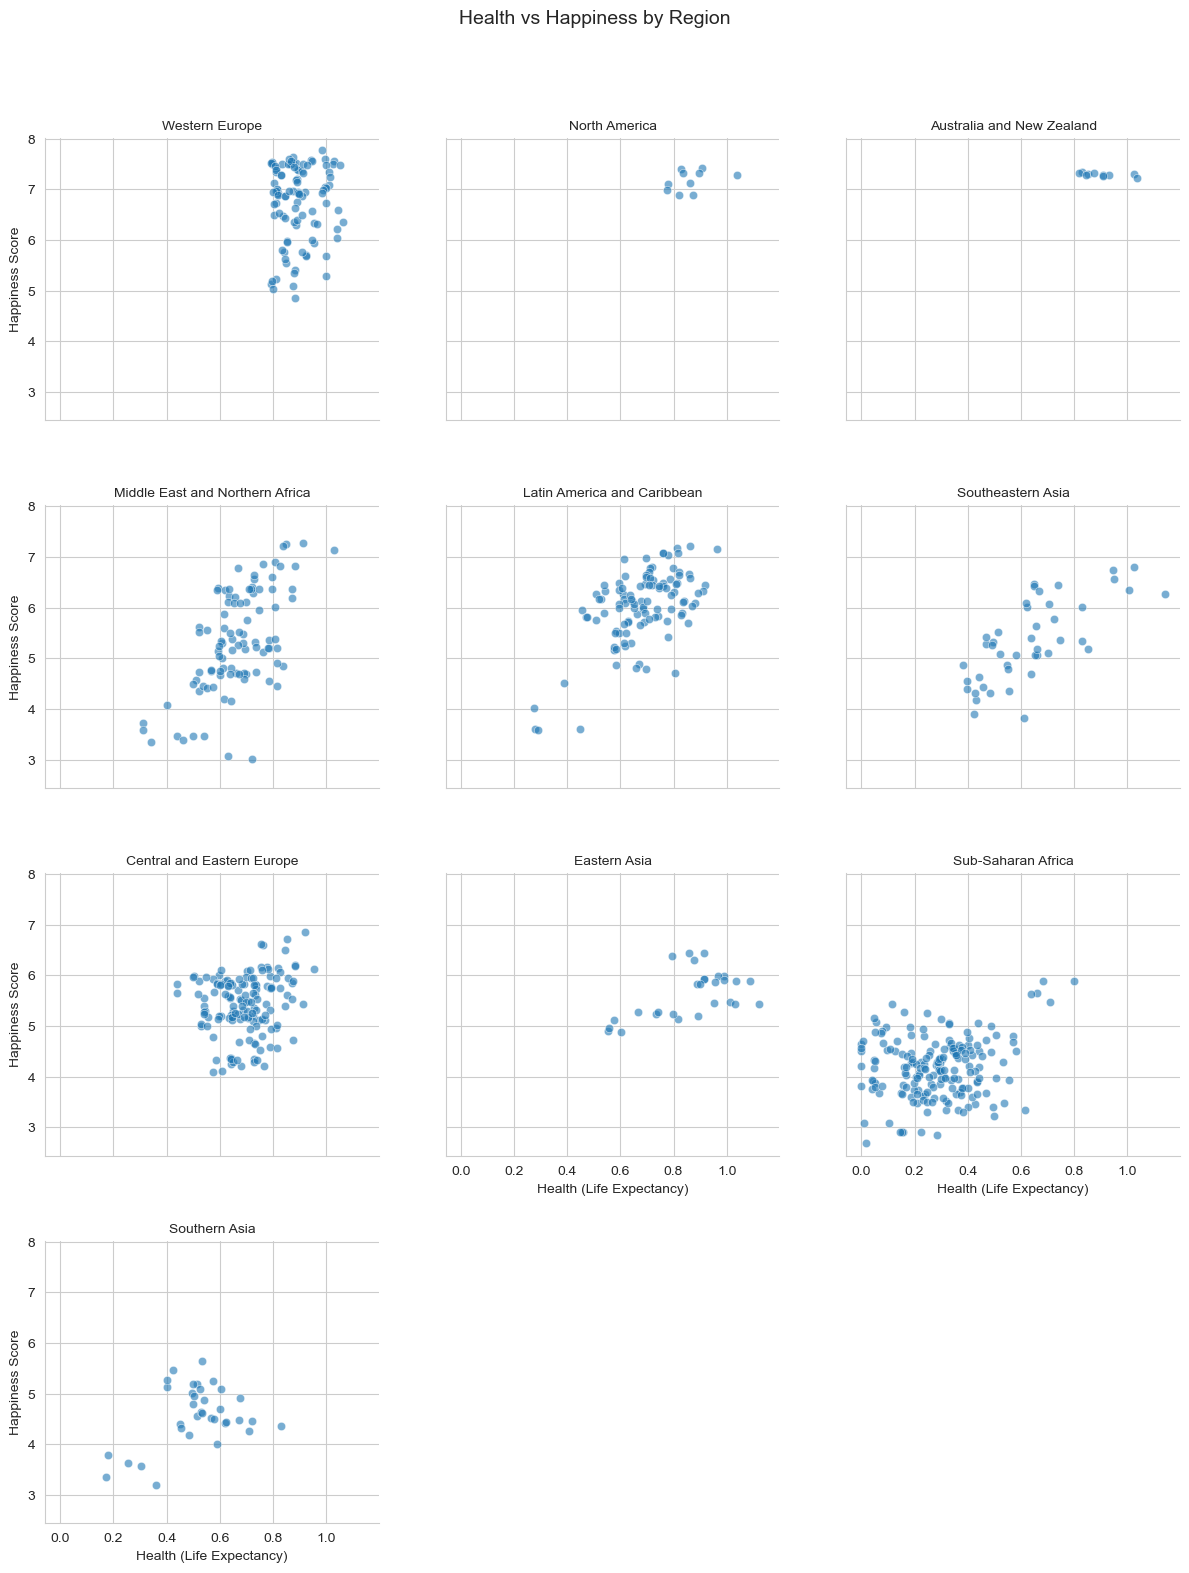

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(df_all, col="Region", col_wrap=3, height=4, sharex=True, sharey=True)

g.map_dataframe(sns.scatterplot, x='Health', y='Happiness Score', alpha=0.6)

g.set_axis_labels("Health (Life Expectancy)", "Happiness Score")
g.set_titles(col_template="{col_name}")

g.fig.subplots_adjust(top=0.9, hspace=0.3, wspace=0.2)
g.fig.suptitle('Health vs Happiness by Region', fontsize=14)

plt.show()

### Results and Interpretation

The FacetGrid visualization highlights the relationship between health (life expectancy) and happiness across regions.

- Most regions show a positive trend, where higher health values correspond to higher happiness scores.
- Western Europe, North America, and Australia and New Zealand exhibit strong clustering at high health and high happiness levels, indicating stable and well-developed conditions.
- Regions like Sub-Saharan Africa and Southern Asia show lower health and lower happiness, with more dispersed data points.
- Middle East & Northern Africa and Latin America display moderate clustering with visible upward trends.
- Central & Eastern Europe and Eastern Asia show moderate relationships with some variability.

Overall, the positive relationship between health and happiness is consistent across regions, though the strength and spread vary depending on regional development levels.

## Q9: Clustering of Countries Based on Happiness Factors

### Objective
To identify groups of countries with similar happiness profiles using hierarchical clustering.

### Approach
- Compute correlation matrix of key variables
- Use Seaborn clustermap to visualize hierarchical clustering
- Observe grouped patterns among variables

### Expected Outcome
To detect clusters of related variables and identify similarities in happiness determinants.

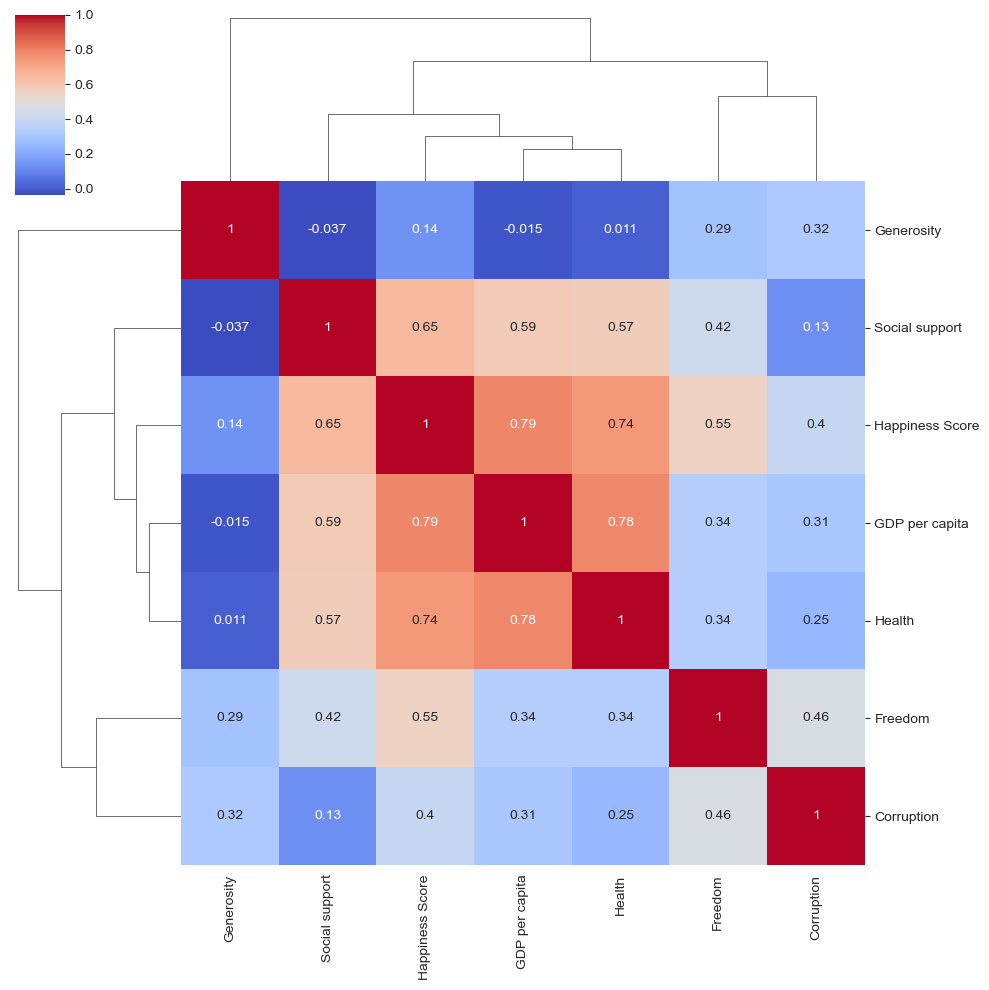

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_all[['Happiness Score','GDP per capita','Social support','Health','Freedom','Generosity','Corruption']].corr()

sns.clustermap(corr, annot=True, cmap='coolwarm')

plt.show()

### Results and Interpretation

The clustermap reveals clear groupings among the variables based on their correlations.

- Happiness Score clusters closely with GDP per capita, Health, and Social support, indicating these are the strongest contributors to overall well-being.
- GDP per capita and Health form a tight cluster, suggesting a strong interrelationship between economic prosperity and life expectancy.
- Freedom shows moderate association with the main cluster but is relatively independent compared to core factors.
- Generosity appears weakly correlated with most variables and is positioned separately in the clustering.
- Corruption forms a loose association with Freedom but remains less strongly connected to the main happiness cluster.

Overall, the clustering highlights that economic and social stability factors are the primary drivers of happiness, while generosity plays a minimal role.

## Q10: Heatmap of Happiness Components by Region and Year

### Objective
To analyze how happiness-related factors vary across regions over time.

### Approach
- Compute average happiness score by region and year
- Pivot the data into a matrix format
- Visualize using a heatmap

### Expected Outcome
To identify temporal trends and regional differences in happiness scores.

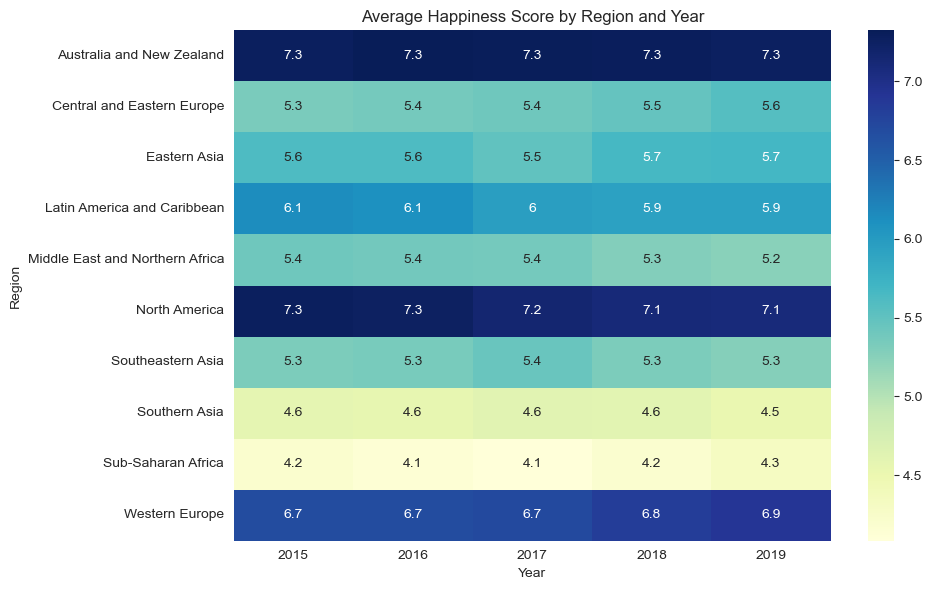

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = df_all.pivot_table(
    values='Happiness Score',
    index='Region',
    columns='Year',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))

sns.heatmap(pivot, annot=True, cmap='YlGnBu')

plt.title('Average Happiness Score by Region and Year')
plt.tight_layout()
plt.show()

### Results and Interpretation

The heatmap illustrates the variation of average happiness scores across regions over time.

- Australia and New Zealand and North America consistently maintain the highest happiness scores across all years, indicating stable well-being.
- Western Europe also shows high scores with a slight increasing trend over time.
- Sub-Saharan Africa and Southern Asia consistently remain at the lower end of the scale.
- Latin America and Eastern Asia maintain moderate happiness levels with minor fluctuations.
- Central and Eastern Europe shows a gradual improvement over the years.
- Middle East and Northern Africa shows a slight decline in recent years.

Overall, the heatmap highlights persistent regional disparities in happiness, with developed regions maintaining higher and more stable scores compared to developing regions.

## Temporal and Regional Trends

### Temporal Trends (Across Years)
The analysis of happiness scores from 2015 to 2019 shows relatively stable global trends with minor fluctuations.

- A slight increase is observed from 2015 to 2016.
- A noticeable dip occurs around 2017, indicating a temporary decline in global well-being.
- Post-2017, happiness scores recover and show a gradual upward trend, reaching higher levels by 2019.

Overall, global happiness remains fairly stable over time, with short-term variations likely influenced by economic or geopolitical factors.



### Regional Trends (Across Regions)
Significant disparities exist between regions:

- **High-performing regions**:  
  Australia and New Zealand, North America, and Western Europe consistently maintain the highest happiness scores with minimal variation over time.

- **Moderate regions**:  
  Latin America, Eastern Asia, and Central & Eastern Europe show mid-range happiness levels with gradual improvements.

- **Low-performing regions**:  
  Sub-Saharan Africa and Southern Asia consistently report lower happiness scores, indicating persistent developmental challenges.

- Some regions, such as Central & Eastern Europe, show steady improvement, while others like the Middle East and Northern Africa show slight declines.

## Overall Results and Findings

This case study analyzed global happiness trends from 2015 to 2019 using multiple socio-economic indicators and visualizations.

### Key Findings

1. **Temporal Trends**
Global happiness scores show a generally stable trend with minor fluctuations, including a dip around 2017 followed by gradual recovery. This suggests short-term global disturbances but overall resilience in well-being.

2. **Economic Influence**
GDP per capita exhibits a strong positive correlation with happiness. Countries with higher economic prosperity consistently report higher happiness levels, confirming the importance of financial stability.

3. **Social Support and Health**
Social support and health (life expectancy) are among the strongest predictors of happiness. Regions with better healthcare systems and stronger social structures demonstrate higher and more stable happiness scores.

4. **Freedom and Governance**
Freedom to make life choices shows a clear positive relationship with happiness. Corruption, while moderately correlated, indicates that governance quality also plays a role in shaping well-being.

5. **Regional Disparities**
Significant differences exist across regions:
- Developed regions (North America, Western Europe, Australia & New Zealand) consistently rank highest.
- Developing regions (Sub-Saharan Africa, Southern Asia) show lower happiness levels.
- Some regions demonstrate gradual improvement over time, indicating development progress.

6. **Distribution Patterns**
Happiness and generosity are unevenly distributed globally. Generosity, in particular, shows a right-skewed distribution, indicating that high generosity is less common.

7. **Multivariate Relationships**
Correlation and clustering analyses reveal that happiness is influenced by a combination of factors rather than a single variable. Economic, social, and health indicators form a strong interconnected cluster.


### Final Conclusion

Happiness is a multidimensional construct influenced by economic, social, and health-related factors. While temporal variations are relatively small, regional disparities are significant and persistent. The findings emphasize that sustainable improvements in well-being require not only economic growth but also strong social support systems, better healthcare, and enhanced individual freedom.